In [0]:
from delta.tables import DeltaTable
import time

base_path = "abfss://data@stdevwesteuropewrmp.dfs.core.windows.net"

read_path_gold = base_path + "/gold/hotel_weather_metrics"

hotel_weather_metrics = spark.read\
    .format("delta")\
    .option('inferSchema', True)\
    .load(read_path_gold)

hotel_weather_metrics.show()

+----------+------------------+-------+-----------+----------+----------+----------+---------+
| wthr_date|              city|country|hotel_count|avg_tmpr_c|max_tmpr_c|min_tmpr_c|tmpr_diff|
+----------+------------------+-------+-----------+----------+----------+----------+---------+
|2017-09-16|          Rockford|     US|          2|      22.7|      22.7|      22.7|      0.0|
|2017-09-19|        Paddington|     GB|         19|      10.5|      10.5|      10.5|      0.0|
|2017-09-28|Amsterdam Zuidoost|     NL|          4|      15.9|      15.9|      15.9|      0.0|
|2016-10-02|             Boone|     US|          1|      16.8|      16.8|      16.8|      0.0|
|2016-10-07|           Griante|     US|          1|       8.1|       8.1|       8.1|      0.0|
|2016-10-11|           Neihart|     US|          1|      -7.7|      -7.7|      -7.7|      0.0|
|2016-10-13|          Appleton|     US|          1|       3.8|       3.8|       3.8|      0.0|
|2016-10-15|            Vinita|     US|          1

In [0]:
import pyspark.sql.functions as F

#Top 5 cities
top_5_cities = hotel_weather_metrics \
    .groupBy("city", "country") \
    .agg(
        F.max("hotel_count").alias("max_daily_hotels")
    ) \
    .orderBy(F.col("max_daily_hotels").desc()) \
    .limit(5)

cities_list = top_5_cities.collect()
top_5_cities_list = [city[0] for city in cities_list]
print(top_5_cities_list)

['Paris', 'London', 'Barcelona', 'Milan', 'Amsterdam']


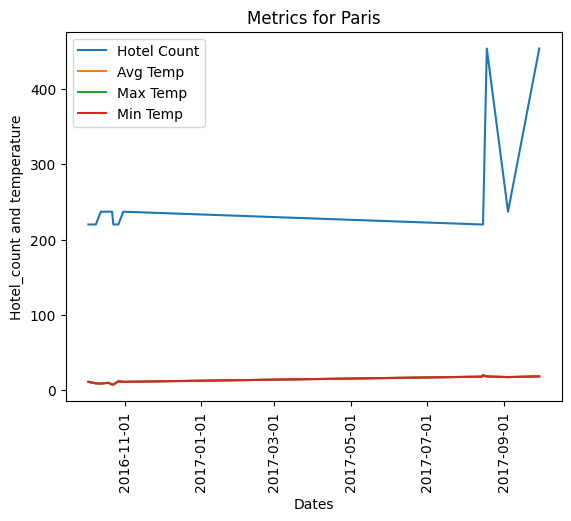

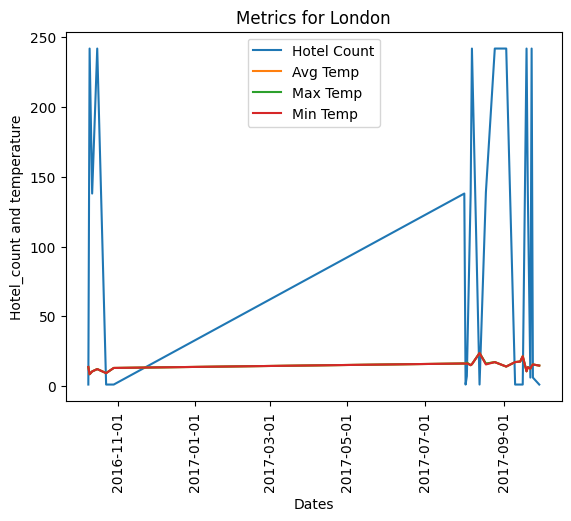

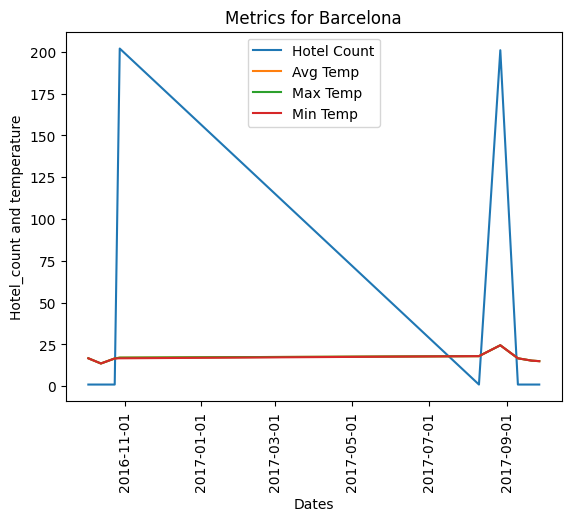

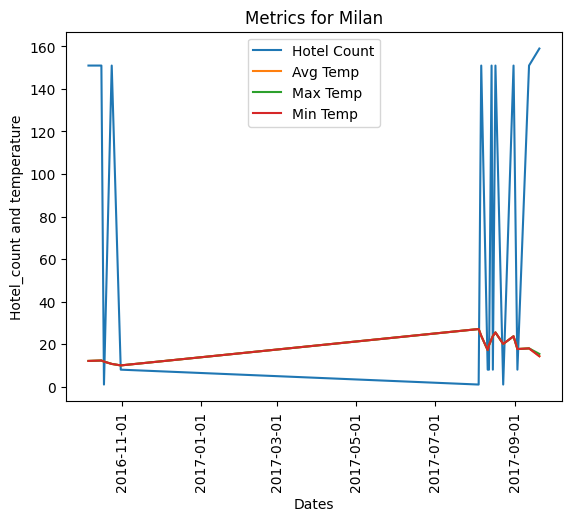

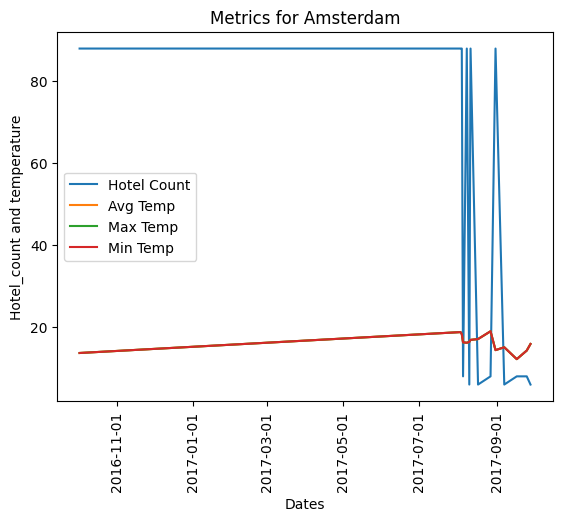

In [0]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
df_list = {}
for city in top_5_cities_list:
    city_metric = hotel_weather_metrics.select(
        'wthr_date', 'hotel_count', 'avg_tmpr_c', 'max_tmpr_c', 'min_tmpr_c'
        ).where(
            F.col('city') == F.lit(city))\
        .orderBy('wthr_date').collect()
    df_list[city] = city_metric
    dates = [str(metric[0]) for metric in city_metric]
    dates = [datetime.strptime(d, "%Y-%m-%d") for d in dates]

    hotel_count = [metric[1] for metric in city_metric]
    avg_temp = [metric[2] for metric in city_metric]
    max_temp = [metric[3] for metric in city_metric]
    min_temp = [metric[4] for metric in city_metric]
    plt.title(f"Metrics for {city}")
    plt.xlabel('Dates')
    plt.ylabel('Hotel_count and temperature')
    plt.plot(dates, hotel_count, label='Hotel Count')
    plt.plot(dates, avg_temp, label='Avg Temp')
    plt.plot(dates, max_temp, label='Max Temp')
    plt.plot(dates, min_temp, label='Min Temp')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation = 90)
    plt.legend()
    plt.show()
# print(dates)
# print(hotel_count)
# print(avg_temp)
# print(max_temp)
# print(min_temp)


In [0]:
import matplotlib.pyplot as plt
df_list = {}
for city in top_5_cities_list:
    city_metric = hotel_weather_metrics.select(
        'wthr_date', 'hotel_count', 'avg_tmpr_c', 'max_tmpr_c', 'min_tmpr_c'
        ).where(
            F.col('city') == F.lit(city))\
        .orderBy('wthr_date')
    df_list[city] = city_metric

In [0]:
df_Paris = df_list['Paris']
df_Paris.display()

wthr_date,hotel_count,avg_tmpr_c,max_tmpr_c,min_tmpr_c
2016-10-03,220,10.699999999999996,10.7,10.7
2016-10-09,220,8.699999999999994,8.7,8.7
2016-10-13,237,8.399999999999999,8.4,8.4
2016-10-19,237,9.399999999999999,9.4,9.4
2016-10-22,237,7.199999999999996,7.2,7.2
2016-10-23,220,7.099999999999998,7.1,7.1
2016-10-27,220,11.399999999999995,11.4,11.4
2016-10-31,237,10.699999999999996,10.7,10.7
2017-08-14,220,17.60000000000001,17.6,17.6
2017-08-15,220,19.399999999999984,19.4,19.4


Databricks visualization. Run in Databricks to view.

In [0]:
df = df_list['London']
df.display()

wthr_date,hotel_count,avg_tmpr_c,max_tmpr_c,min_tmpr_c
2016-10-09,1,13.6,13.6,13.6
2016-10-10,242,8.399999999999997,8.4,8.4
2016-10-12,138,10.400000000000002,10.4,10.4
2016-10-16,242,12.100000000000009,12.1,12.1
2016-10-23,1,9.2,9.2,9.2
2016-10-29,1,12.9,12.9,12.9
2017-08-01,138,16.1,16.1,16.1
2017-08-02,1,15.9,15.9,15.9
2017-08-03,7,16.628571428571426,16.7,16.2
2017-08-06,138,14.9,14.9,14.9


Databricks visualization. Run in Databricks to view.

In [0]:
df = df_list['Barcelona']
df.display()

wthr_date,hotel_count,avg_tmpr_c,max_tmpr_c,min_tmpr_c
2016-10-03,1,16.7,16.7,16.7
2016-10-13,1,13.6,13.6,13.6
2016-10-24,1,16.6,16.6,16.6
2016-10-28,202,17.098086124401924,17.1,16.7
2017-08-10,1,18.0,18.0,18.0
2017-08-27,201,24.5,24.5,24.5
2017-09-10,1,16.7,16.7,16.7
2017-09-21,1,15.3,15.3,15.3
2017-09-27,1,15.0,15.0,15.0


Databricks visualization. Run in Databricks to view.

In [0]:
df = df_list['Milan']
df.display()

wthr_date,hotel_count,avg_tmpr_c,max_tmpr_c,min_tmpr_c
2016-10-06,151,12.1,12.1,12.1
2016-10-16,151,12.300000000000004,12.3,12.3
2016-10-18,1,11.8,11.8,11.8
2016-10-24,151,10.699999999999996,10.7,10.7
2016-10-31,8,10.0,10.0,10.0
2017-08-04,1,27.1,27.1,27.1
2017-08-06,151,23.89999999999999,23.9,23.9
2017-08-11,8,17.2,17.2,17.2
2017-08-12,8,19.5,19.5,19.5
2017-08-14,151,22.39999999999999,22.4,22.4


Databricks visualization. Run in Databricks to view.

In [0]:
df = df_list['Amsterdam']
df.display()

wthr_date,hotel_count,avg_tmpr_c,max_tmpr_c,min_tmpr_c
2016-10-02,88,13.699999999999996,13.7,13.7
2017-08-03,88,18.800000000000004,18.8,18.8
2017-08-04,88,18.300000000000004,18.3,18.3
2017-08-05,8,16.3,16.3,16.3
2017-08-08,88,16.199999999999996,16.2,16.2
2017-08-10,6,16.400000000000002,16.4,16.4
2017-08-11,88,16.9,16.9,16.9
2017-08-17,6,17.099999999999998,17.1,17.1
2017-08-27,8,19.0,19.0,19.0
2017-08-31,88,14.400000000000002,14.4,14.4


Databricks visualization. Run in Databricks to view.